In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('system_event_data.csv')

In [3]:
df.head()

,event_id,moisture_after,moisture_before,moisture_gain,moisture_rate,node_id,time,tree_id,valve_duration
0,1-1-1781080223537,62.0,57.7,4.3,0.36,1,2026-06-10 08:30:23.537,1,11.8
1,1-1-1781080211736,66.2,59.9,6.3,0.61,1,2026-06-10 08:30:11.736,1,10.3
2,1-4-1781080201435,71.4,52.8,18.6,1.96,1,2026-06-10 08:30:01.435,4,9.5
3,1-3-1781080191934,67.4,53.5,13.9,0.73,1,2026-06-10 08:29:51.934,3,19.0
4,1-3-1781080172934,68.7,59.8,8.9,1.07,1,2026-06-10 08:29:32.934,3,8.3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         173 non-null    object 
 1   moisture_after   173 non-null    float64
 2   moisture_before  173 non-null    float64
 3   moisture_gain    173 non-null    float64
 4   moisture_rate    173 non-null    float64
 5   node_id          173 non-null    int64  
 6   time             173 non-null    object 
 7   tree_id          173 non-null    int64  
 8   valve_duration   173 non-null    float64
dtypes: float64(5), int64(2), object(2)
memory usage: 12.3+ KB


### Train Test Split

In [5]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=23)

print("Train count:", len(df_train))
print("Test count:", len(df_test))

Train count: 138
Test count: 35


In [6]:
# Drop columns that are not needed for training
df_train.drop(columns=['node_id', 'tree_id', 'event_id', 'time'], inplace=True)
df_train.to_csv('train_dataset.csv', index=False)

df_train.reset_index(drop=True, inplace=True)
df_train.head(3)

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
0,62.0,54.6,7.4,0.50,14.7
1,67.4,53.5,13.9,0.73,19.0
2,66.5,56.4,10.1,0.51,19.8


In [7]:
# Save testing dataset
df_test.drop(columns=['node_id', 'tree_id', 'event_id', 'time'], inplace=True)
df_test.to_csv('test_dataset.csv', index=False)

df_test.reset_index(drop=True, inplace=True)
df_test.head(3)

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
0,64.4,55.8,8.6,0.96,9.0
1,71.1,59.8,11.3,0.85,13.3
2,61.8,53.0,8.8,0.51,17.1


In [8]:
# Feature scaling
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()

train_transformed = scalar.fit_transform(df_train)
test_transformed = scalar.transform(df_test)

#### Hyperparameter Tuner

In [9]:
from keras.models import Model
from keras.layers import Dense

In [10]:
from keras_tuner.tuners import RandomSearch
from keras_tuner import Objective
from keras.layers import Input

In [11]:
input_dim = train_transformed.shape[1]

In [12]:
def build_model(hp):
    num_layers = hp.Int('num_layers', 1, 3)

    # Encoder
    inputs = Input(shape=(input_dim,))
    x = inputs

    encoder_units = []

    for i in range(num_layers):
        units = hp.Int(
            f'units_{i}',
            min_value=4,
            max_value=16,
            step=2
        )

        encoder_units.append(units)

        x = Dense(units, activation='relu')(x)

    # Latent space
    latent_dim = hp.Int('latent_dim', 1, 3)
    latent = Dense(latent_dim, activation='relu',name='latent')(x)

    x = latent

    # Decoder
    for units in reversed(encoder_units):
        x = Dense(units, activation='relu')(x)

    # Output layer
    outputs = Dense(input_dim, activation='linear')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model

In [13]:
tuner = RandomSearch(
    hypermodel=build_model,
    objective=Objective('val_loss', direction='min'),
    max_trials=20,
    directory='tuner_results',
    project_name='smart_irrigation_system'
)

Reloading Tuner from tuner_results\smart_irrigation_system\tuner0.json


In [14]:
tuner.search(
    train_transformed, 
    train_transformed, 
    epochs=15, 
    batch_size=5000, 
    validation_data=(test_transformed, test_transformed))

In [15]:
tuner.results_summary()

Results summary
Results in tuner_results\smart_irrigation_system
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 14 summary
Hyperparameters:
num_layers: 1
units_0: 6
latent_dim: 3
units_1: 12
units_2: 10
Score: 0.2011297345161438

Trial 18 summary
Hyperparameters:
num_layers: 2
units_0: 4
latent_dim: 3
units_1: 8
units_2: 4
Score: 0.2150319218635559

Trial 01 summary
Hyperparameters:
num_layers: 1
units_0: 12
latent_dim: 1
Score: 0.24219202995300293

Trial 13 summary
Hyperparameters:
num_layers: 2
units_0: 12
latent_dim: 1
units_1: 10
units_2: 10
Score: 0.24598489701747894

Trial 04 summary
Hyperparameters:
num_layers: 3
units_0: 14
latent_dim: 3
units_1: 4
units_2: 4
Score: 0.24637314677238464

Trial 05 summary
Hyperparameters:
num_layers: 2
units_0: 14
latent_dim: 1
units_1: 10
units_2: 8
Score: 0.2704854905605316

Trial 10 summary
Hyperparameters:
num_layers: 3
units_0: 14
latent_dim: 2
units_1: 12
units_2: 10
Score: 0.27527865767478943

Trial 19 summary
Hy

In [16]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            35 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116 (464.00 B)

 Trainable params: 116 (464.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = best_model.fit(train_transformed, 
               train_transformed, 
               epochs=100, 
               batch_size=5000, 
               validation_data=(test_transformed, test_transformed))

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1834 - mae: 0.3403 - val_loss: 0.1995 - val_mae: 0.3464
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1821 - mae: 0.3388 - val_loss: 0.1980 - val_mae: 0.3450
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1808 - mae: 0.3374 - val_loss: 0.1966 - val_mae: 0.3437
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1796 - mae: 0.3360 - val_loss: 0.1952 - val_mae: 0.3423
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.1784 - mae: 0.3346 - val_loss: 0.1939 - val_mae: 0.3409
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1773 - mae: 0.3331 - val_loss: 0.1927 - val_mae: 0.3394
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1762 - mae: 0.3317 - val_loss: 0.1915 - val_mae: 0.3381
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.1751 - mae: 0.3304 - val_loss: 0.1903 - val_mae: 0.3368
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.1740 - mae: 0.

### Analisis Histori Training

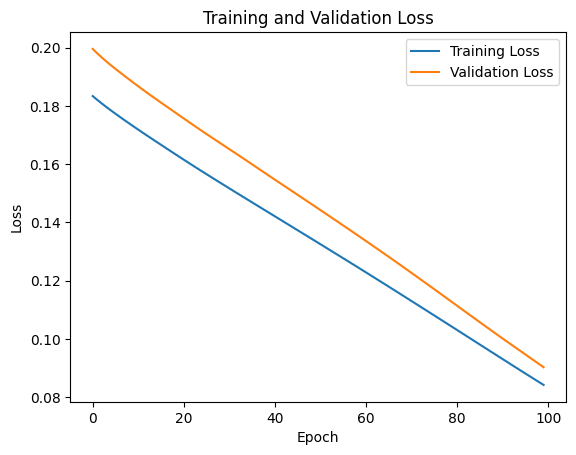

In [18]:
# Visualise the history of training
plt.plot(history.history['loss'], label= "Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [19]:
recon_train = best_model.predict(train_transformed)
recon_train_loss = np.mean(np.abs(train_transformed - recon_train), axis=1)
print("recon_train_loss:", recon_train_loss[:5])
print("Average reconstruction loss for training set:", np.mean(recon_train_loss))

recon_test = best_model.predict(test_transformed)
recon_test_loss = np.mean(np.abs(test_transformed - recon_test), axis=1)
print("recon_test_loss:", recon_test_loss[:5])
print("Average reconstruction loss for test set:", np.mean(recon_test_loss))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
recon_train_loss: [0.12382968 0.14357967 0.2074721  0.18530009 0.11630345]
Average reconstruction loss for training set: 0.21701933365430928
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
recon_test_loss: [0.14016123 0.25715847 0.15109346 0.29105555 0.22299388]
Average reconstruction loss for test set: 0.22519574133795803


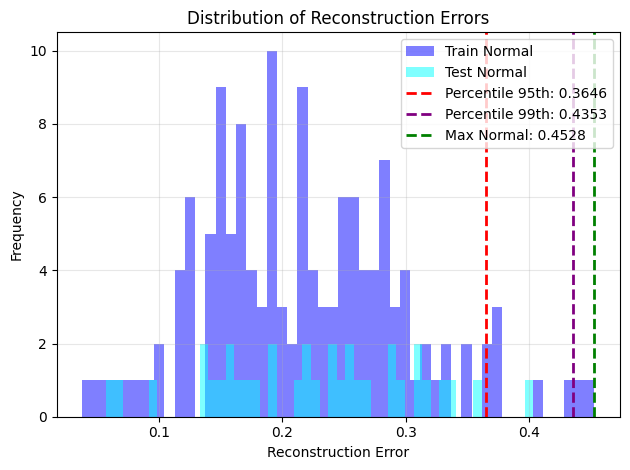

In [20]:
max_normal = max(np.max(recon_train_loss), np.max(recon_test_loss))
percentile_95_normal = np.percentile(recon_train_loss, 95)
percentile_99_normal = np.percentile(recon_train_loss, 99)

# Plot distribusi histogram
plt.hist(recon_train_loss, bins=50, alpha=0.5, label='Train Normal', color='blue')
plt.hist(recon_test_loss, bins=50, alpha=0.5, label='Test Normal', color='cyan')
plt.axvline(percentile_95_normal, color='red', linestyle='--', linewidth=2, label=f'Percentile 95th: {percentile_95_normal:.4f}')
plt.axvline(percentile_99_normal, color='purple', linestyle='--', linewidth=2, label=f'Percentile 99th: {percentile_99_normal:.4f}')
plt.axvline(max_normal, color='green', linestyle='--', linewidth=2, label=f'Max Normal: {max_normal:.4f}')
plt.xlabel('Reconstruction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Reconstruction Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

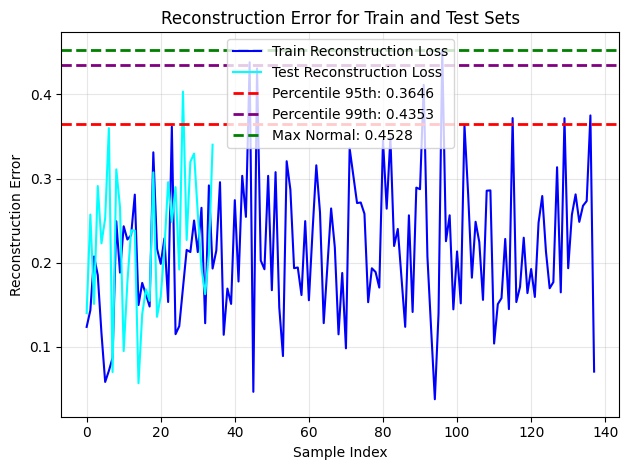

In [21]:
# Grafik garis perbandingan antara mse global asli dan rekonstruksi
plt.plot(recon_train_loss, label='Train Reconstruction Loss', color='blue')
plt.plot(recon_test_loss, label='Test Reconstruction Loss', color='cyan')
plt.axhline(percentile_95_normal, color='red', linestyle='--', linewidth=2, label=f'Percentile 95th: {percentile_95_normal:.4f}')
plt.axhline(percentile_99_normal, color='purple', linestyle='--', linewidth=2, label=f'Percentile 99th: {percentile_99_normal:.4f}')
plt.axhline(max_normal, color='green', linestyle='--', linewidth=2, label=f'Max Normal: {max_normal:.4f}')
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error for Train and Test Sets')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# choose threshold
threshold = percentile_99_normal
print("Chosen threshold:", threshold)

Chosen threshold: 0.43526086755388727


In [23]:
features = df_train.columns.to_list()

df_train_recon = scalar.inverse_transform(recon_train)
df_train_recon = pd.DataFrame(df_train_recon, columns=features)
df_train_recon.head()

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
0,63.363533,53.797909,12.444097,0.823989,13.070549
1,63.506428,54.177494,13.548157,0.840841,14.242339
2,63.561924,54.460571,14.530893,0.880739,15.109921
3,63.457806,54.131405,13.511689,0.855530,14.096210
4,63.409458,53.849674,12.512168,0.812141,13.233607


In [24]:
df_train.head()

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
0,62.0,54.6,7.4,0.50,14.7
1,67.4,53.5,13.9,0.73,19.0
2,66.5,56.4,10.1,0.51,19.8
3,68.6,53.1,15.5,0.81,19.2
4,66.0,52.5,13.5,0.83,16.3


In [25]:
def comparison_plot(df, df_recon):
    features = df.columns.to_list()
    fig, axes = plt.subplots(5, 1, figsize=(12,15))

    for i, feature in enumerate(features):

        axes[i].plot(
            df.iloc[:, i],
            label='Actual'
        )

        axes[i].plot(
            df_recon.iloc[:, i],
            label='Reconstructed'
        )

        axes[i].set_title(feature)
        axes[i].legend()
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()

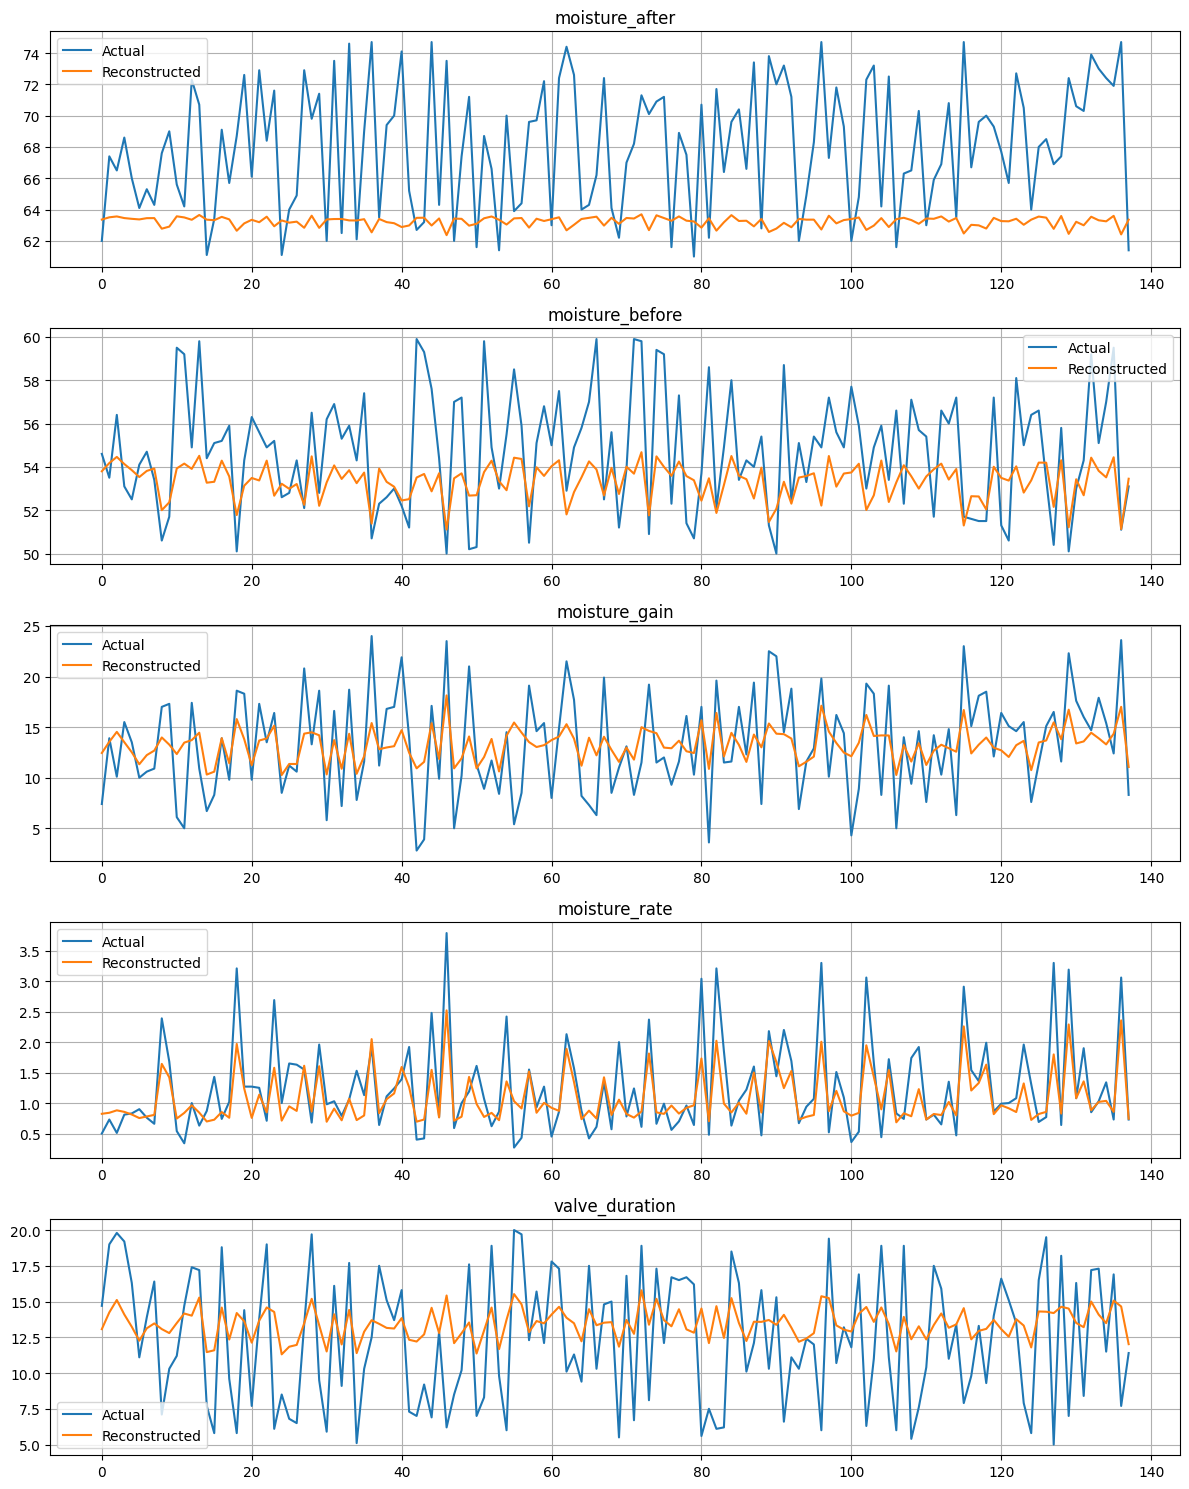

In [26]:
comparison_plot(df_train, df_train_recon)

In [27]:
df_test_recon = scalar.inverse_transform(recon_test)
df_test_recon = pd.DataFrame(df_test_recon, columns=features)
df_test_recon.head()

,moisture_after,moisture_before,moisture_gain,moisture_rate,valve_duration
0,63.383007,53.498329,11.160046,0.739919,12.162016
1,63.522381,54.146633,13.372391,0.824721,14.150480
2,63.293999,53.658024,13.216849,0.978426,13.522023
3,63.537014,54.419949,14.442743,0.884081,14.983340
4,63.235432,53.337246,12.233062,0.950184,12.652002


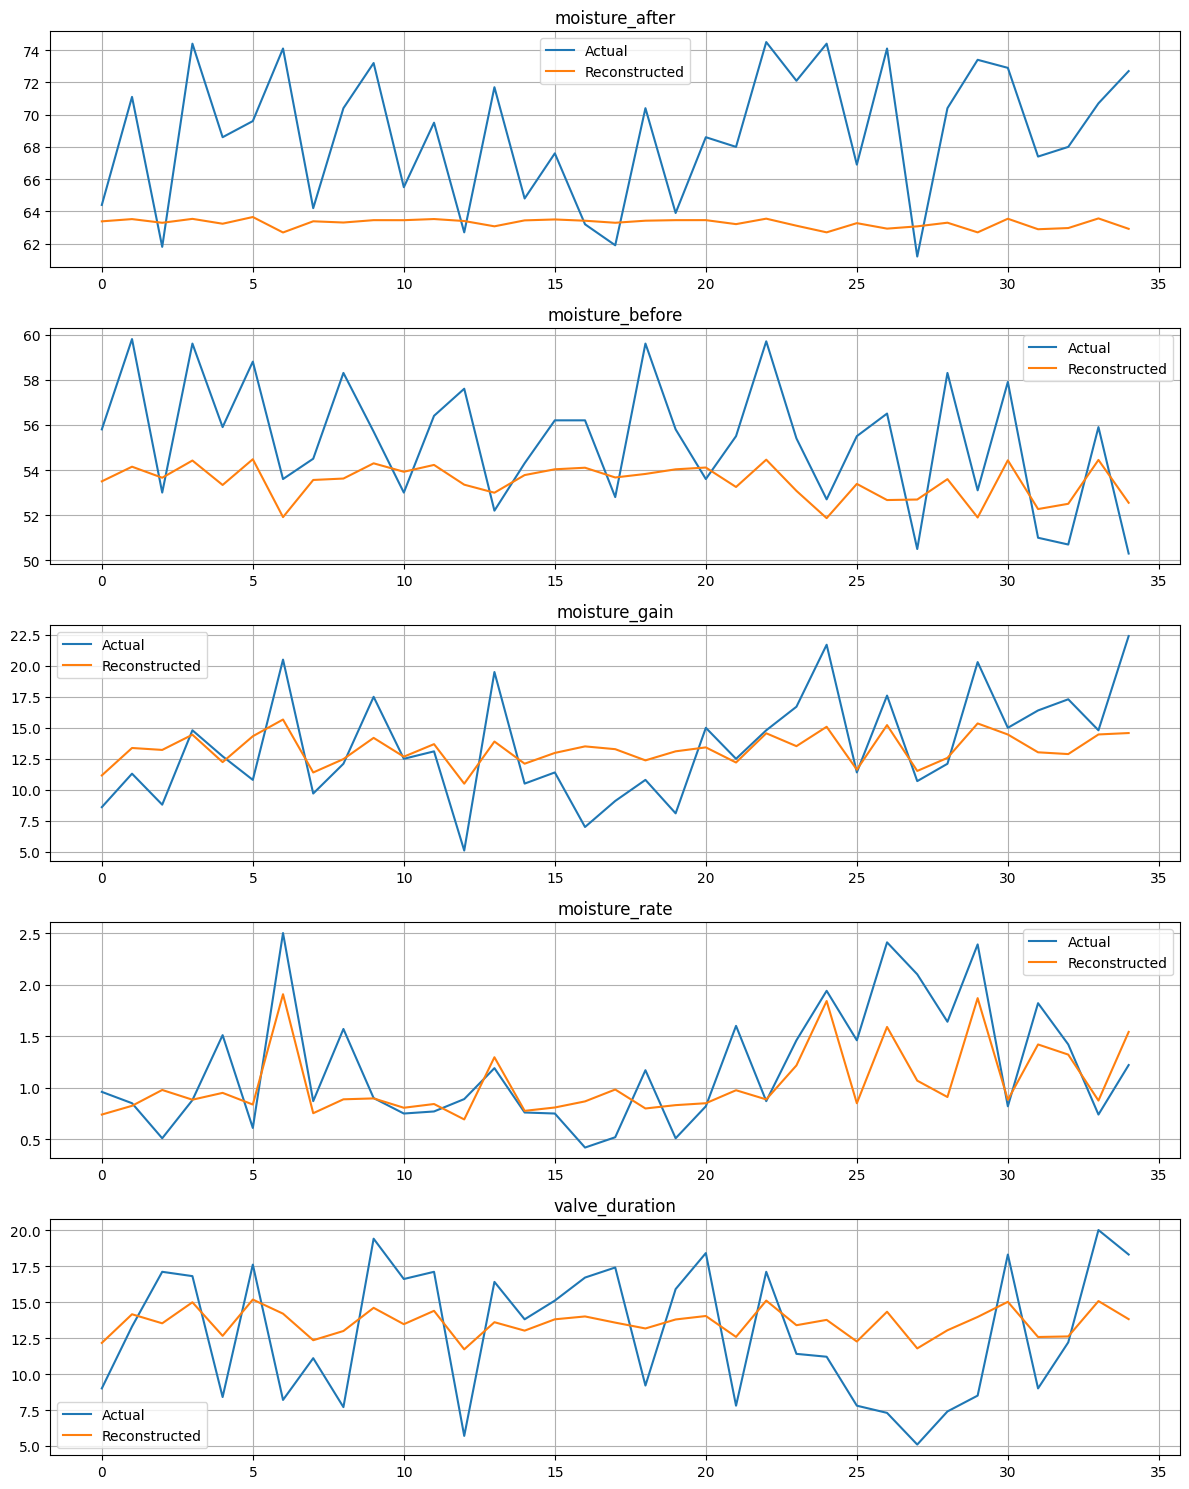

In [28]:
# Visualize the actual vs reconstructed values for the test set
comparison_plot(df_test, df_test_recon)

In [29]:
# Save the best model
best_model.save('best_autoencoder_model.keras')

In [30]:
# Prediksi untuk data baru (misalnya data uji) yang faulty
data = df_test.iloc[0].values
data[1] = 20  # Modifikasi data untuk membuatnya faulty
data = data.reshape(1, -1)  # Contoh data uji yang faulty
normalized_data = scalar.transform(data)  # Normalisasi data baru
recon_data = best_model.predict(normalized_data)

error_new_data = np.abs(normalized_data - recon_data)
mean_error_new_data = np.mean(error_new_data)
fault_ratio = mean_error_new_data / threshold

print("Original data:", data)
print("Normalized new data:", normalized_data)
print("Reconstructed data:", recon_data)
print("Global MSE for new data:", mean_error_new_data)
print("Fault Ratio for new data:", fault_ratio)
print("Status:", "Anomalous" if fault_ratio > 1 else "Normal")
print("Severity:", "High" if fault_ratio > 2 else "Medium" if fault_ratio > 1 else "Low")
print("Individual errors for new data:", error_new_data)
print("Dominant feature:", features[np.argmax(error_new_data)])
print("Dominant error:", np.max(error_new_data))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Original data: [[64.4  20.    8.6   0.96  9.  ]]
Normalized new data: [[ 0.24817518 -3.03030303  0.27358491  0.19602273  0.26666667]]
Reconstructed data: [[-0.04874157 -0.7687777   1.0293641   1.7058622   0.7827804 ]]
Global MSE for new data: 1.0680348878210806
Fault Ratio for new data: 2.4537810941362723
Status: Anomalous
Severity: High
Individual errors for new data: [[0.29691675 2.2615253  0.7557792  1.50983944 0.51611374]]
Dominant feature: moisture_before
Dominant error: 2.261525302222281


c:\Users\lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
